In [5]:
## Testing the IOU Implementation

import json

from microlane.evaluation.evaluator import evaluate_prediction
from microlane.schemas.prediction import Prediction
from microlane.schemas.sample import Sample
from scripts.core.read_image import read_image


In [6]:
def parse_path(path):
    parts = path.split("/")
    augmentation = parts[-3]  # normal / camera_shake / etc.
    model        = parts[-4]  # lanenet
    dataset      = parts[-5]  # tusimple
    return model, dataset, augmentation

In [7]:

prediction_file  = "/home/suyog/desktop/projects/microlane/results/experiment/tusimple/ufld/normal/experiment_2026-05-17_12-59-20/prediction.json"
prediction_index = 212

model, dataset, augmentation = parse_path(prediction_file)

with open(prediction_file) as f:
    j = json.load(f)
    
j = j[prediction_index] 

pred = Prediction(
    lanes=j["lanes"],
    h_samples=j["h_samples"],
    run_time=j["run_time"],
    samples=[
         Sample(
            image_path=s["image_path"],
            image=read_image(s["image_path"]),
            lanes=s["lanes"],
            h_samples=s["h_samples"],
            dataset=s["dataset"],
            blur=s["blur"],
            lighting=s["lighting"],
            rotation=s["rotation"],
            zoom=s["zoom"],
            motion_blur=s["motion_blur"],
        )
        for s in j["samples"]
    ],
)

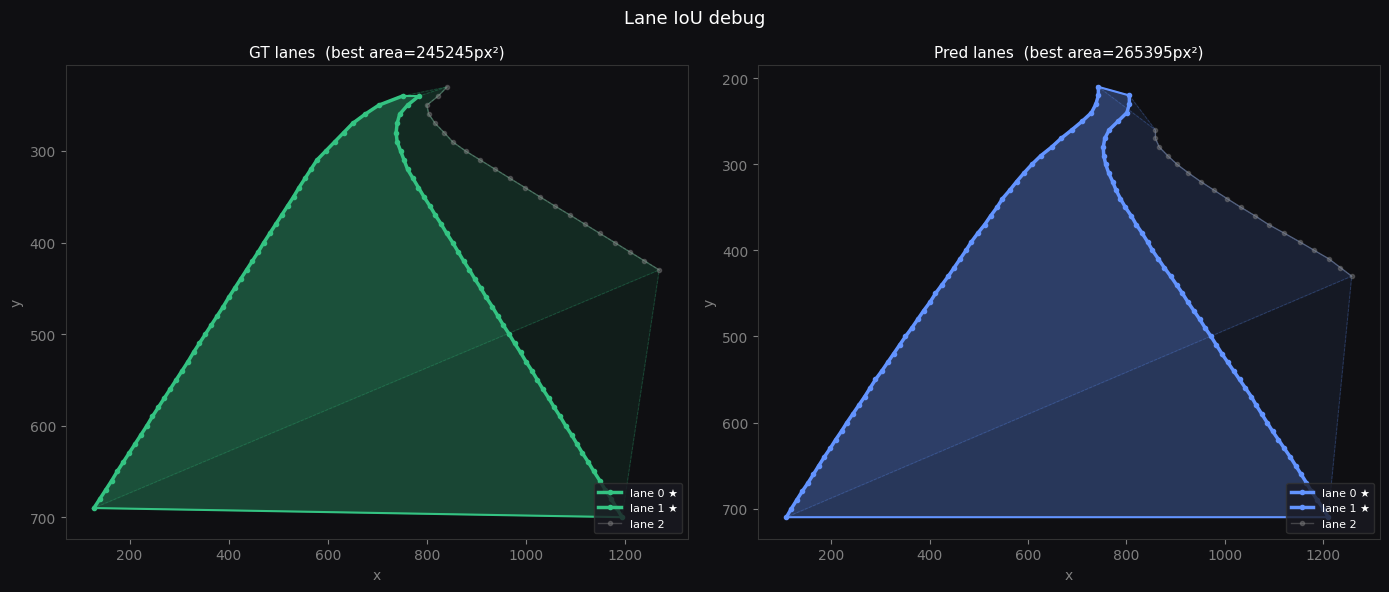

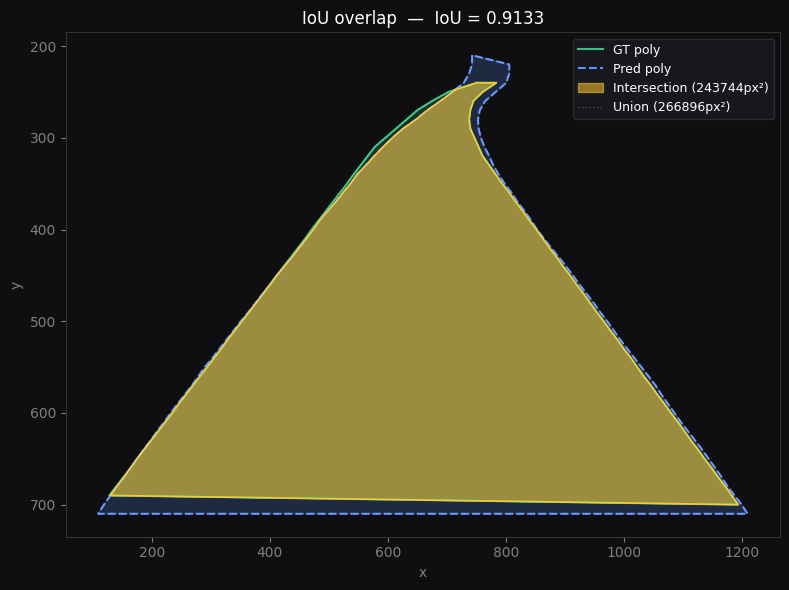

Evaluation(experiment_number=0, dataset='tusimple', model='ufld', augmentation='normal', raw_file='/home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492628091114320051_0/20.jpg', processed_samples=['/home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492628091114320051_0/20.jpg'], run_time=0.002713918685913086, accuracy=np.float64(0.9285714285714285), IOU=0.9132548387091597, fn=0.0, fp=0.0)

In [8]:
evaluate_prediction(pred, 0, model, dataset, augmentation)